# Intermediate NN

In [49]:
#########################     LIBRARIES     ##########################
from keras.models import Model
from keras.layers import Dense, Input
#from keras.layers.merge import concatenate
from tensorflow.keras.layers import concatenate     # PROBLEMA SEMBRA RISOLTO COSI !!!
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from math import pi
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossValGP, transfBestparam
from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf

# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [50]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [61]:
########################     PREPARATION      ##########################
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)
reaction_HF_test_original=reaction_HF_test
U_HF_test_original=U_HF_test
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[300]
Nepo=[10000]


noise_stddev1=[0.01,0.005,0.02]
noise_stddev2=[0.005,0.003,0.01]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]



r2_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
mse_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF R^2
r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



U_HF_list = []
U_LF_list = []

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 6.84612375e-01  9.60531263e-01]
 [ 8.18107604e-01  7.22929090e-01]
 [ 2.42714261e-01  9.30051439e-01]
 [ 1.03061130e-01  8.40991636e-01]
 [ 3.87882517e-02  9.05638578e-01]
 [ 1.83673469e-01  2.63976118e-01]
 [ 4.28571429e-01  8.26238774e-01]
 [ 7.53101203e-01  2.11476921e-01]
 [ 4.24549561e-01  7.89026238e-01]
 [ 7.75510204e-01  1.38467619e-01]
 [ 5.17391618e-01  6.99008921e-01]
 [ 1.50431188e-01  2.52270857e-01]
 [ 6.56322357e-01  9.86827838e-01]
 [ 4.30984396e-01  8.46991643e-01]
 [ 9.49140555e-01  2.71835183e-01]
 [ 6.53061224e-01  9.77249996e-01]
 [ 3.10261954e-01  7.74549884e-01]
 [ 8.36734694e-01  8.91491136e-01]
 [ 2.25105510e-01  7.94361183e-01]
 [ 9.17696592e-01  6.95575152e-01]
 [ 6.04983403e-01  5.66191361e-01]
 [ 4.53592740e-01  9.7898666

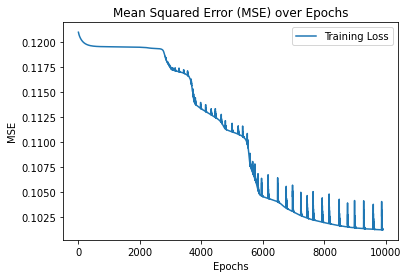

Test MSE: 0.13584637
Test MSE HF: 0.13546442
Test MSE LF: 0.13278347
R^2: -0.1375
R^2 HF: -0.1967
R^2 LF: -0.0612

 



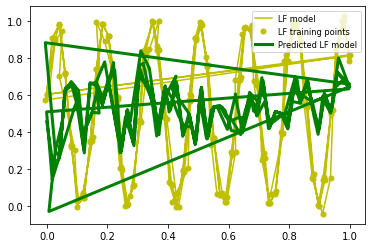

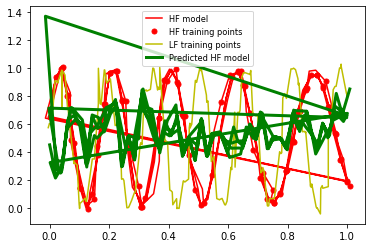

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.19669496389918217]
Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.26530612  0.99977164]
 [ 0.79479502  0.42760264]
 [ 0.1279478   0.57138664]
 [ 0.27823496  0.98353533]
 [ 0.39546013  0.43702346]
 [ 0.85138794  0.97133851]
 [ 0.87755102  0.98542002]
 [ 0.28571429  0.95557281]
 [ 0.42857143  0.82623877]
 [ 0.46818633  0.99971511]
 [ 0.79591837  0.44348626]
 [ 0.42958433  0.8350966 ]
 [ 0.93877551  0.42423168]
 [ 0.31393672  0.7367695 ]
 [ 0.83673469  0.89149114]
 [ 0.57273297  0.09514513]
 [ 0.16326531  0.05340303]
 [ 0.92821063  0.56799362]
 [ 0.1587497   0.12403914]
 [ 0.69413311  0.90836374]
 [ 0.16208766  0.07186494]
 [ 0.91836735  0.68796692]
 [ 0.71659141  0.70794222]
 [ 0.30732162  0.80292716]
 [ 0.7755102   0.13846762]
 [ 0.47124683  0.99741307]
 [ 0.0700971   0.99854854]


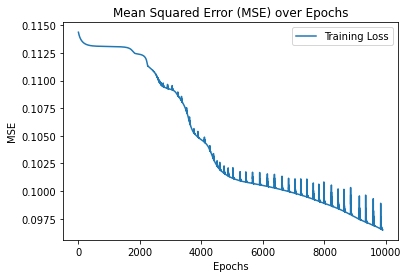

Test MSE: 0.13919343
Test MSE HF: 0.13645026
Test MSE LF: 0.13572331
R^2: -0.2193
R^2 HF: -0.2054
R^2 LF: -0.1848

 



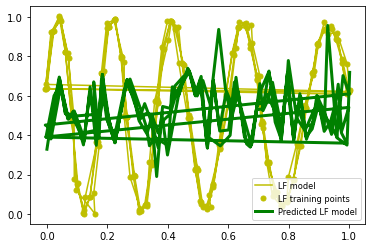

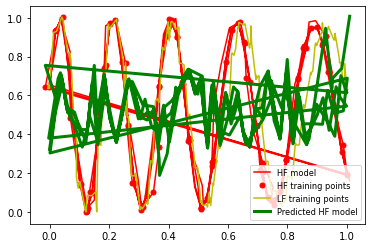

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.20540387233612556]
Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.34379436  0.35159781]
 [ 0.73469388  0.48137907]
 [ 0.77587369  0.14411991]
 [ 0.18544944  0.29077735]
 [ 0.91769659  0.69557515]
 [ 0.67307641  0.99493565]
 [ 0.18867422  0.33884959]
 [ 0.94002375  0.40639574]
 [ 0.63592117  0.88562919]
 [ 0.42454956  0.78902624]
 [ 0.75312157  0.21116422]
 [ 0.82032243  0.74652422]
 [ 0.57273297  0.09514513]
 [ 0.18396009  0.26831602]
 [ 0.38491191  0.28268839]
 [ 0.66092136  0.99593049]
 [ 0.03878825  0.90563858]
 [ 0.32653061  0.58951289]
 [ 0.02040816  0.7474196 ]
 [ 0.24271426  0.93005144]
 [ 0.10306113  0.84099164]
 [ 0.6049834   0.56619136]
 [ 0.55391694  0.19893617]
 [ 0.20408163  0.55445913]
 [ 0.87936422  0.98017515]
 [ 0.87755102  0.98542002]
 [ 0.08163265  0.97249451]

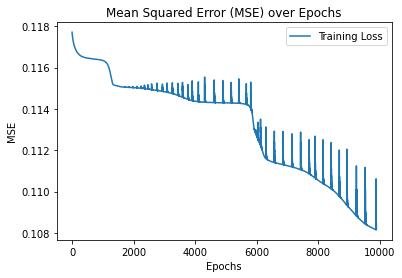

Test MSE: 0.11582845
Test MSE HF: 0.11370766
Test MSE LF: 0.11343017
R^2: 0.0004
R^2 HF: -0.0045
R^2 LF: 0.0373

 



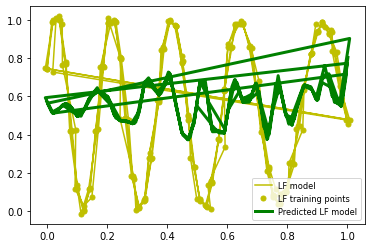

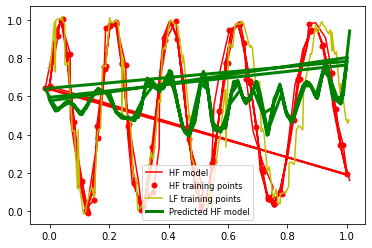

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.00449540742676402]
Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 1.58749699e-01  1.24039136e-01]
 [ 5.52856481e-01  2.15232481e-01]
 [ 5.45267070e-01  3.29849434e-01]
 [ 7.44082442e-01  3.47357982e-01]
 [ 6.73469388e-01  9.94296233e-01]
 [ 5.72732970e-01  9.51451320e-02]
 [ 6.92510737e-02  9.99176105e-01]
 [ 3.69961165e-01  5.17267621e-02]
 [ 7.80099572e-01  2.09441333e-01]
 [ 1.61305561e-01  8.41125591e-02]
 [ 8.18107604e-01  7.22929090e-01]
 [ 5.30612245e-01  5.36548377e-01]
 [ 2.85284539e-01  9.57540749e-01]
 [ 3.87755102e-01  3.25231350e-01]
 [ 8.12162346e-01  6.55348904e-01]
 [ 1.85449445e-01  2.90777347e-01]
 [ 2.02834769e-01  5.38054412e-01]
 [ 1.88674222e-01  3.38849588e-01]
 [ 1.42857143e-01  3.65341024e-01]
 [ 8.57142857e-01  9.88830826e-01]
 [ 6.32653061e-01  8.60633218

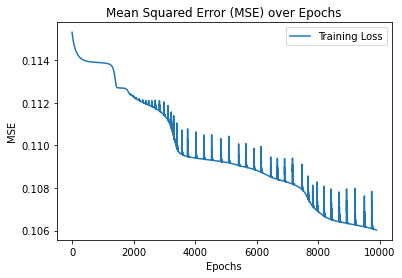

Test MSE: 0.12230070
Test MSE HF: 0.12002968
Test MSE LF: 0.12270876
R^2: -0.0648
R^2 HF: -0.0603
R^2 LF: -0.0581

 



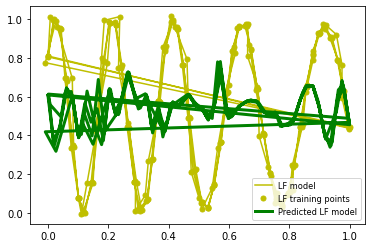

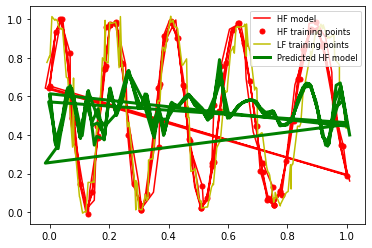

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.06034426345858357]
Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.45359274  0.97898667]
 [ 0.36779132  0.01766507]
 [ 0.46615808  0.99996809]
 [ 0.08409926  0.9627421 ]
 [ 0.89795918  0.88160624]
 [ 0.22145912  0.7582846 ]
 [ 0.86468284  0.99951451]
 [ 0.8181076   0.72292909]
 [ 0.51739162  0.69900892]
 [ 0.30732162  0.80292716]
 [ 0.83673469  0.89149114]
 [ 0.24489796  0.94210524]
 [ 0.65632236  0.98682784]
 [ 0.51347567  0.74164695]
 [ 0.59183673  0.38515014]
 [ 0.93877551  0.42423168]
 [ 0.29879125  0.87536221]
 [ 0.67346939  0.99429623]
 [ 0.61848713  0.72703524]
 [ 0.18831243  0.33349736]
 [ 0.7755102   0.13846762]
 [ 0.67465341  0.99214078]
 [ 0.63286459  0.86232047]
 [ 0.38345927  0.2607293 ]
 [ 0.44840848  0.95915431]
 [ 0.81216235  0.6553489 ]
 [ 0.0365522   0.89018882]


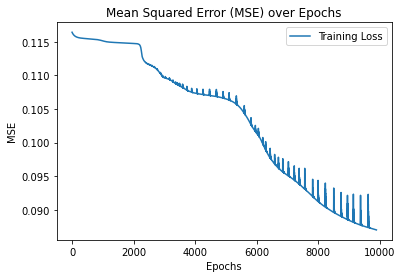

Test MSE: 0.17205910
Test MSE HF: 0.15321442
Test MSE LF: 0.16753160
R^2: -0.4441
R^2 HF: -0.3535
R^2 LF: -0.3451

 



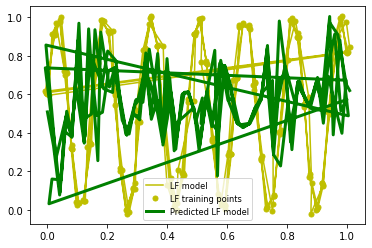

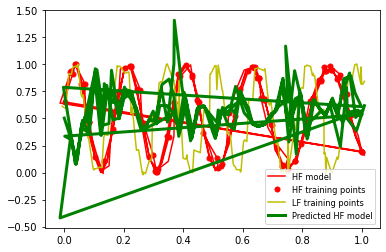

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.3534987425823388]
Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 2.85284539e-01  9.57540749e-01]
 [ 5.45267070e-01  3.29849434e-01]
 [ 9.01618758e-01  8.53033127e-01]
 [ 7.74418684e-01  1.21467700e-01]
 [ 6.96823990e-01  8.89881889e-01]
 [ 1.58749699e-01  1.24039136e-01]
 [ 6.35921166e-01  8.85629193e-01]
 [ 9.79591837e-01  2.01636152e-01]
 [ 6.73469388e-01  9.94296233e-01]
 [ 6.84612375e-01  9.60531263e-01]
 [ 1.50431188e-01  2.52270857e-01]
 [ 5.17391618e-01  6.99008921e-01]
 [ 9.82561232e-01  2.47085417e-01]
 [ 7.53121570e-01  2.11164221e-01]
 [ 5.71428571e-01  7.47300936e-02]
 [ 4.66158080e-01  9.99968089e-01]
 [ 8.77210821e-01  9.86315144e-01]
 [ 9.77539257e-01  1.69957205e-01]
 [ 8.40992602e-02  9.62742103e-01]
 [ 2.23366255e-02  7.67198322e-01]
 [ 1.85449445e-01  2.90777347e

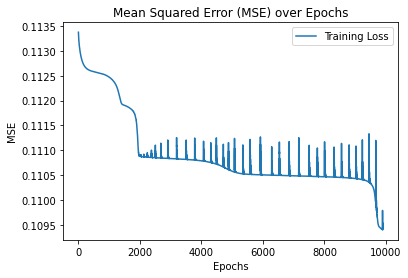

Test MSE: 0.11193982
Test MSE HF: 0.11032533
Test MSE LF: 0.11302737
R^2: 0.0146
R^2 HF: 0.0254
R^2 LF: 0.0036

 



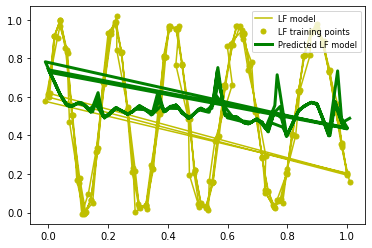

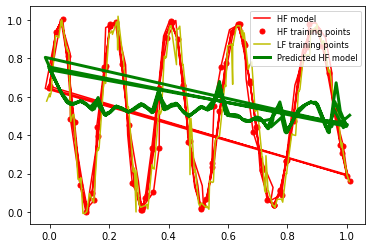

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[0.025384194768996338]
Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.94002375  0.40639574]
 [ 0.20228896  0.53080797]
 [ 0.25571475  0.9852389 ]
 [ 0.08163265  0.97249451]
 [ 0.87755102  0.98542002]
 [ 0.67465341  0.99214078]
 [ 0.22510551  0.79436118]
 [ 0.9001731   0.86466266]
 [ 0.6504664   0.96779606]
 [ 0.30612245  0.81401209]
 [ 0.24154253  0.92313158]
 [ 0.36779132  0.01766507]
 [ 0.77587369  0.14411991]
 [ 0.06122449  0.99634834]
 [ 0.79146405  0.37974104]
 [ 0.38491191  0.28268839]
 [ 0.50758241  0.80047865]
 [ 0.48979592  0.93472445]
 [ 0.36867148  0.03148633]
 [ 0.0365522   0.89018882]
 [ 0.57142857  0.07473009]
 [ 0.91939381  0.67617641]
 [ 0.05919169  0.99311458]
 [ 0.95918367  0.1172721 ]
 [ 0.06925107  0.9991761 ]
 [ 0.43232108  0.85796603]
 [ 0.71428571  0.73305187]

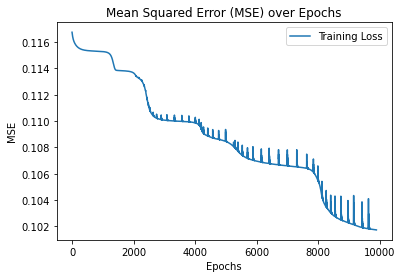

Test MSE: 0.12125724
Test MSE HF: 0.11728171
Test MSE LF: 0.12032273
R^2: -0.0510
R^2 HF: -0.0361
R^2 LF: -0.0282

 



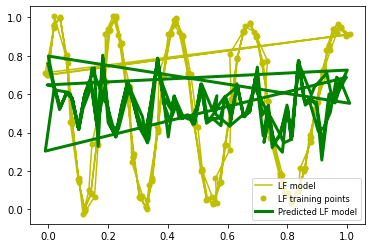

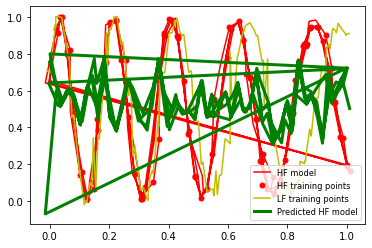

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.03606861980650322]
Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.79591837  0.44348626]
 [ 0.48979592  0.93472445]
 [ 0.03878825  0.90563858]
 [ 0.86468284  0.99951451]
 [ 0.52695085  0.58416803]
 [ 0.16130556  0.08411256]
 [ 0.54590229  0.32041353]
 [ 0.64879932  0.96087292]
 [ 0.84043233  0.9162865 ]
 [ 0.22145912  0.7582846 ]
 [ 0.28528454  0.95754075]
 [ 0.36734694  0.01068549]
 [ 0.57603153  0.14657291]
 [ 0.73469388  0.48137907]
 [ 0.39546013  0.43702346]
 [ 0.26686965  0.99999492]
 [ 0.70830783  0.79359716]
 [ 0.27823496  0.98353533]
 [ 0.61038265  0.63398015]
 [ 0.97959184  0.20163615]
 [ 0.90161876  0.85303313]
 [ 0.50758241  0.80047865]
 [ 0.12468906  0.61262912]
 [ 0.68461238  0.96053126]
 [ 0.05919169  0.99311458]
 [ 0.46615808  0.99996809]
 [ 0.53061224  0.53654838]


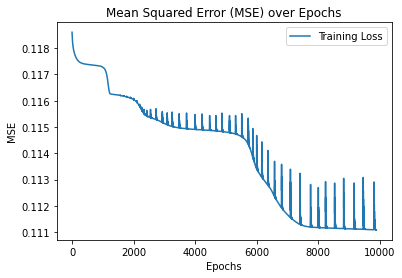

Test MSE: 0.12164760
Test MSE HF: 0.11606461
Test MSE LF: 0.12777194
R^2: -0.0479
R^2 HF: -0.0253
R^2 LF: -0.0788

 



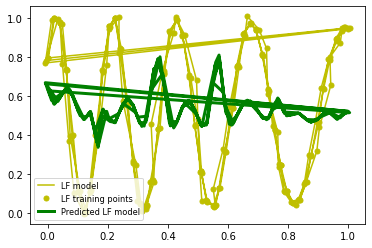

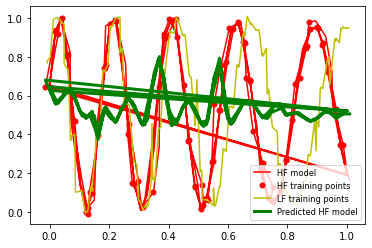

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.025316698718496067]
Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.94002375  0.40639574]
 [ 0.47124683  0.99741307]
 [ 0.57142857  0.07473009]
 [ 0.73522203  0.47409091]
 [ 0.94914056  0.27183518]
 [ 0.30612245  0.81401209]
 [ 0.77441868  0.1214677 ]
 [ 0.4309844   0.84699164]
 [ 0.0194828   0.73768426]
 [ 0.08409926  0.9627421 ]
 [-0.00288196  0.46029647]
 [ 0.67307641  0.99493565]
 [ 0.40293484  0.53937878]
 [ 0.87721082  0.98631514]
 [ 0.54590229  0.32041353]
 [ 0.57273297  0.09514513]
 [ 0.89444389  0.90631147]
 [ 0.61848713  0.72703524]
 [ 1.          0.5       ]
 [ 0.1040946   0.83209802]
 [ 0.46615808  0.99996809]
 [ 0.44646492  0.95007244]
 [ 0.79591837  0.44348626]
 [ 0.20408163  0.55445913]
 [ 0.95918367  0.1172721 ]
 [ 0.67465341  0.99214078]
 [ 0.84043233  0.9162865 ]

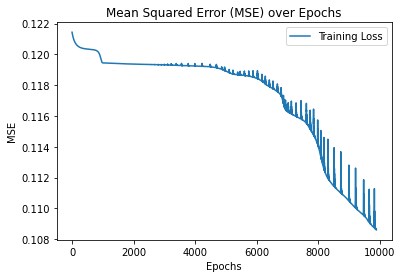

Test MSE: 0.12785920
Test MSE HF: 0.12340154
Test MSE LF: 0.13343245
R^2: -0.0759
R^2 HF: -0.0901
R^2 LF: -0.0766

 



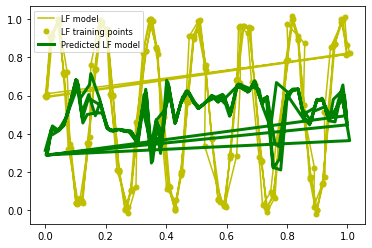

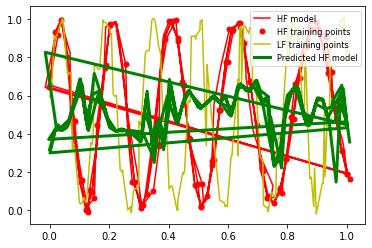

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.09013133576901455]
Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 1.00110865  0.51500496]
 [ 0.87268812  0.99553019]
 [ 0.66092136  0.99593049]
 [ 0.51020408  0.77512456]
 [ 0.7531012   0.21147692]
 [ 0.40816327  0.60663988]
 [ 0.31026195  0.77454988]
 [ 0.51739162  0.69900892]
 [ 0.75312157  0.21116422]
 [ 0.44646492  0.95007244]
 [ 0.63265306  0.86063322]
 [ 0.63592117  0.88562919]
 [ 0.29879125  0.87536221]
 [ 0.52695085  0.58416803]
 [ 0.07469122  0.99206628]
 [ 0.46818633  0.99971511]
 [ 0.65306122  0.97725   ]
 [ 0.97959184  0.20163615]
 [ 0.24489796  0.94210524]
 [ 0.39546013  0.43702346]
 [ 0.42454956  0.78902624]
 [ 0.06925107  0.9991761 ]
 [ 0.7755102   0.13846762]
 [ 0.32653061  0.58951289]
 [ 0.98256123  0.24708542]
 [ 0.55285648  0.21523248]
 [ 0.36734694  0.01068549]


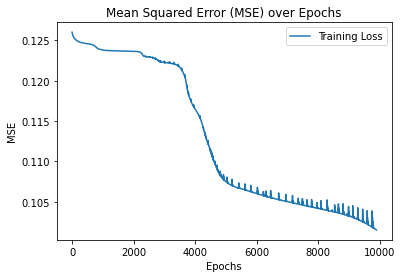

Test MSE: 0.15181279
Test MSE HF: 0.14637179
Test MSE LF: 0.14273432
R^2: -0.2713
R^2 HF: -0.2931
R^2 LF: -0.1457

 



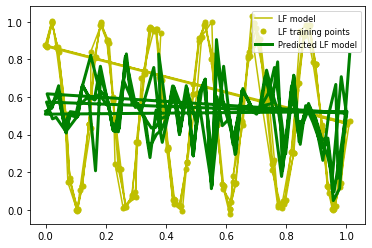

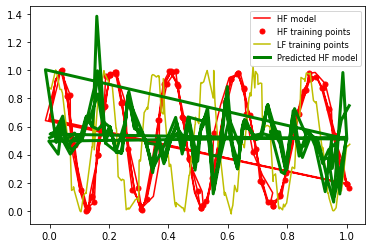

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.2930508264045295]
Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 0.82500041  0.79335726]
 [ 0.44840848  0.95915431]
 [ 0.54590229  0.32041353]
 [ 0.97753926  0.16995721]
 [ 0.28528454  0.95754075]
 [ 0.94914056  0.27183518]
 [ 0.22343895  0.77818895]
 [ 0.26686965  0.99999492]
 [ 0.98256123  0.24708542]
 [ 0.32098782  0.65751935]
 [ 0.34379436  0.35159781]
 [ 0.18831243  0.33349736]
 [ 0.3493827   0.26817288]
 [ 0.36734694  0.01068549]
 [ 0.79591837  0.44348626]
 [ 0.83673469  0.89149114]
 [ 0.74408244  0.34735798]
 [ 0.3877551   0.32523135]
 [ 0.64193633  0.92549226]
 [ 0.18867422  0.33884959]
 [ 0.52793954  0.57149317]
 [ 0.16130556  0.08411256]
 [ 0.42857143  0.82623877]
 [ 0.29879125  0.87536221]
 [ 0.28571429  0.95557281]
 [ 0.75312157  0.21116422]
 [-0.01430746  0.29442872]


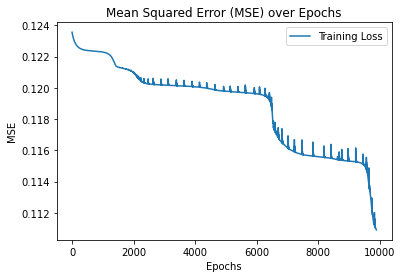

Test MSE: 0.15370525
Test MSE HF: 0.13431092
Test MSE LF: 0.17004265
R^2: -0.2702
R^2 HF: -0.1865
R^2 LF: -0.3290

 



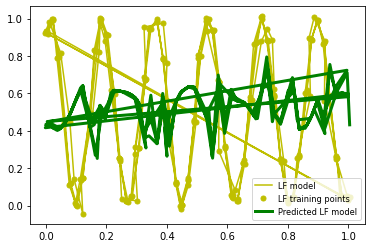

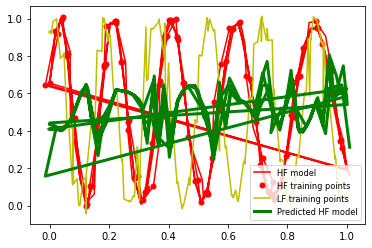

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

[-0.18650493882140395]
Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
[300]
[[ 1.83673469e-01  2.63976118e-01]
 [ 1.94828024e-02  7.37684263e-01]
 [ 5.10204082e-01  7.75124555e-01]
 [ 6.35921166e-01  8.85629193e-01]
 [ 8.64682836e-01  9.99514506e-01]
 [ 5.08249712e-01  7.94152281e-01]
 [ 8.77551020e-01  9.85420021e-01]
 [ 9.28210630e-01  5.67993624e-01]
 [ 1.03061130e-01  8.40991636e-01]
 [ 1.61305561e-01  8.41125591e-02]
 [ 3.46938776e-01  3.04949106e-01]
 [ 8.63407815e-01  9.98690082e-01]
 [ 9.18367347e-01  6.87966921e-01]
 [ 5.91836735e-01  3.85150136e-01]
 [ 6.18487134e-01  7.27035241e-01]
 [ 7.74418684e-01  1.21467700e-01]
 [ 3.65522037e-02  8.90188819e-01]
 [ 2.44897959e-01  9.42105237e-01]
 [ 3.52025874e-01  2.27955166e-01]
 [ 5.73506122e-01  1.07227368e-01]
 [ 9.40023755e-01  4.06395735

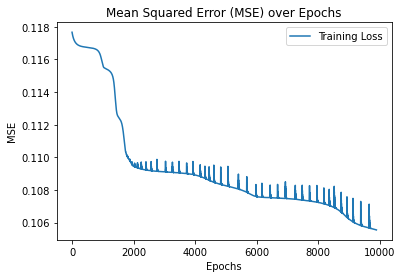

Test MSE: 0.13883353
Test MSE HF: 0.12026616
Test MSE LF: 0.15971035
R^2: -0.1835
R^2 HF: -0.0624
R^2 LF: -0.3212

 



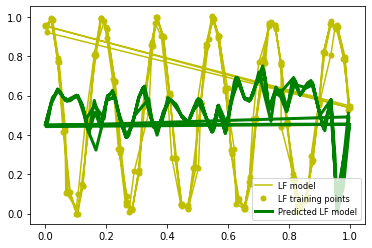

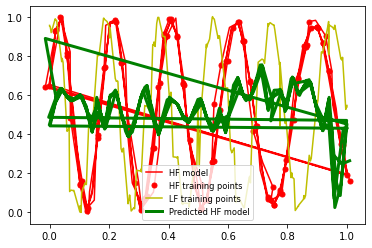

[-0.06243329563188249]
Saving ...
    Discretization  diffusion       R2
0             46.0        0.0 -0.23706
1             46.0        5.0 -0.35788
2             46.0       75.0 -0.21262
3             46.0        1.0 -0.03859
4             28.0        0.0 -0.39685
5             28.0        5.0 -0.11801
6             28.0       75.0 -0.02286
7             28.0        1.0 -0.18416
8             46.0        0.0 -0.19669
9             46.0        5.0 -0.20540
10            46.0       75.0 -0.00450
11            46.0        1.0 -0.06034
12            28.0        0.0 -0.35350
13            28.0        5.0  0.02538
14            28.0       75.0 -0.03607
15            28.0        1.0 -0.02532
16            10.0        0.0 -0.09013
17            10.0        5.0 -0.29305
18            10.0       75.0 -0.18650
19            10.0        1.0 -0.06243
    Discretization  diffusion      MSE
0             46.0        0.0  0.14003
1             46.0        5.0  0.15371
2             46.0       75.0 

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:181: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:183: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7068\1280855909.py:185: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

In [63]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                
                permutation = np.random.permutation(len(reaction_HF_test))
                ### IMPORT LF DATASETs
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                
                reaction_LF_test = normalization(reaction_LF_test)
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                #U_LF_test_original=U_LF_test
                reaction_LF_test_original=reaction_LF_test
                U_LF_test_original=U_LF_test 
                
                noise_stddev1=[0.01,0.005,0.02]
                noise_stddev2=[0.005,0.003,0.01]

                (U_LF_test,reaction_LF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_LF_test,U_LF_test)
                
                # randomization
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                reaction_LF_test_original=np.c_[reaction_LF_test_original, np.abs(np.sin(5*np.pi*reaction_LF_test_original[:, 0]-5*np.pi/6))]
                
                
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )

                test_mse_HF_list = []
                test_mse_LF_list = []
                test_mse_list = []
                r2_HF_list = []
                r2_LF_list = []
                r2_list = []
                            
                MAX_EVAL = 30
                #best paramters obtained by HPO:
                #best_params = {'alpha': 0.031884991755260814, 'epochs': 2.0, 'kernel_init': 'uniform', 'l2weight': 0.002651788904350721, 'lr': 0.00042698780348019073, 'nodes': 114.0, 'opt': 'Adamax'}
                best_params = {'alpha': 0.0965167240033655, 'epochs': 3.0, 'kernel_init': 'uniform', 'l2weight': 0.00021154214219451555, 'lr': 0.0065338127394483905, 'nodes': 128.0, 'opt': 'Adamax'}

                # # reproducibilty porpuse 
                # learning_rate = bestLF_params["lr"]
                # optimizer_type = bestLF_params["opt"]

                # # Fissa i parametri di ottimizzazione
                # if optimizer_type == "Adam":
                #     optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # elif optimizer_type == "Nadam":
                #     optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # elif optimizer_type == "Adamax":
                #     optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # else:
                #     raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                # #
                names=['Inter']
                params=[best_params]
                reaction_norm=np.concatenate((reaction_HF,reaction_LF),axis=0)
                reaction_norm_test=np.concatenate((reaction_HF_test,reaction_LF_test),axis=0)
                reaction_norm_test_original=np.concatenate((reaction_HF_test_original,reaction_LF_test_original),axis=0)

                model= MultiFidelity(names,params=params,data_train_HF=reaction_norm,output_train_HF=np.concatenate((U_train_LF,U_HF)),N=Nepo * int(best_params['epochs']),n=batch_size,do_HPO=False,verbose=False)
            
                U_pred = model.model_list[0].prediction(reaction_norm_test)
                
                U_Pred = np.concatenate((U_pred[0],U_pred[1]),axis=1)
                U_HF_list.append(U_pred[0][:,0])
                U_LF_list.append(U_pred[1][:,0])
                U_test = np.concatenate((U_HF_test,U_LF_test))

                test_mse= np.mean(np.square(U_test- U_Pred[:,0]))
                test_mse_list.append(test_mse)
                print(f"Test MSE: {test_mse:.8f}")

                test_mse_HF = np.mean(np.square(U_HF_test_original- model.model_list[0].prediction(reaction_HF_test_original)[0][:,0]))
                test_mse_HF_list.append(test_mse_HF)
                print(f"Test MSE HF: {test_mse_HF:.8f}")

                test_mse_LF = np.mean(np.square(U_LF_test- model.model_list[0].prediction(reaction_LF_test)[1][:,0]))
                test_mse_LF_list.append(test_mse_LF)
                print(f"Test MSE LF: {test_mse_LF:.8f}")

                r2 = 1 - np.sum(np.square(U_test- U_Pred[:,0])) / np.sum(np.square(U_test - np.mean(U_test)))
                r2_list.append(r2)
                print(f"R^2: {r2:.4f}")

                r2_HF = 1 - np.sum(np.square(U_HF_test_original- model.model_list[0].prediction(reaction_HF_test_original)[0][:,0])) / np.sum(np.square(U_HF_test_original - np.mean(U_HF_test_original)))
                r2_HF_list.append(r2_HF)
                print(f"R^2 HF: {r2_HF:.4f}")

                r2_LF = 1 - np.sum(np.square(U_LF_test- model.model_list[0].prediction(reaction_LF_test)[1][:,0])) / np.sum(np.square(U_LF_test - np.mean(U_LF_test)))
                r2_LF_list.append(r2_LF)
                print(f"R^2 LF: {r2_LF:.4f}")

                print('\n \n')

                plt.figure()
                plt.plot(
                reaction_LF_test[:,0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:,0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:,0],
                model.model_list[0].prediction(reaction_LF_test)[1],
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                reaction_HF[:,0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                
                plt.plot(
                reaction_HF_test[:,0],
                model.model_list[0].prediction(reaction_HF_test)[0],
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()

               
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df = mse_HF_df.append(new, ignore_index=True)
                
                # if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
                # #     save_model(finalModel,"finalModel2NN.h5")
                
                
                ##  SALVATAGGIO CON NUOVA CLASSE?
                print(r2_HF_list)
                if not r2_HF_list[:-1]:
                    model.save()
                elif r2_HF_list[:-1] and r2_HF_list[-1] > max(r2_HF_list[:-1]) and test_mse_HF_list[-1]<min(test_mse_HF_list[:-1]):
                    model.save()
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

In [53]:
reaction_norm=np.concatenate((reaction_HF,reaction_LF),axis=0)
print(reaction_norm.shape)
print(U_pred[0].shape)

(300, 2)
(400, 1)


In [54]:
print(U_Pred[:,0])

[0.6427586  0.4320932  0.49544114 0.5360398  0.5330432  0.45673108
 0.4920994  0.6454963  0.77436507 0.6422696  0.55302674 0.43965662
 0.5444252  0.5506475  0.5549343  0.46389574 0.4951735  0.5970297
 0.7317116  0.5878     0.46684235 0.4938956  0.57174695 0.5511365
 0.5755352  0.46743184 0.4894872  0.54029405 0.5911889  0.53794795
 0.42807025 0.56219554 0.5642694  0.539123   0.5951005  0.46625745
 0.47210416 0.47772542 0.4771189  0.47182465 0.4577049  0.6082336
 0.5150068  0.5177769  0.61349666 0.45915216 0.44042295 0.41148514
 0.4061393  0.40806353 0.6282784  0.4410716  0.4786978  0.53655815
 0.5238124  0.4363024  0.45363593 0.6446058  0.79724216 0.63568485
 0.57910275 0.43627825 0.52431625 0.5525273  0.5479688  0.4335996
 0.4915889  0.60021424 0.70519364 0.58684736 0.45290995 0.54528725
 0.5718602  0.56191576 0.56095743 0.44262666 0.4931609  0.5417751
 0.5859186  0.53118384 0.42865628 0.5721418  0.5393913  0.53363264
 0.5929412  0.48767716 0.4943196  0.48031518 0.49331826 0.4576219
 

In [55]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_new_Lin')

r2_HF_df.to_csv('./Output_new_Lin/r2_HF_lhs.txt', header=True, index=False, sep='\t', mode='a')
mse_HF_df.to_csv('./Output_new_Lin/mse_HF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')
r2_LF_df.to_csv('./Output_new_Lin/r2_LF_lhs.txt', header=True, index=False, sep='\t', mode='a')
mse_LF_df.to_csv('./Output_new_Lin/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')


with open('./Output_new_Lin/U_HF_list.data', 'wb') as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open('./Output_new_Lin/U_LF_list.data', 'wb') as filehandle:
    pickle.dump(U_LF_list, filehandle)
